# Research Question and Analysis Plan

---

## Research Question
**Do sequential patterns reveal temporal or ordering structure that is missed by unordered frequent itemsets, particularly given the bursty transaction timing and sparse co-occurrence matrix?**

This question is significant because the Online Retail II dataset exhibits strong temporal behavior: customers often make multiple purchases within short time windows, and item co-occurrence is extremely sparse. Traditional frequent itemset mining ignores ordering and therefore cannot capture meaningful purchase sequences that unfold over time. By focusing on sequential pattern mining, we can determine whether ordering provides additional explanatory power beyond what unordered itemsets can reveal. This allows us to evaluate whether temporal structure is essential for understanding customer behavior in this dataset.

---

## Analysis Plan

### 1. Data Preparation
- Clean the Online Retail II dataset by removing cancellations, negative quantities, and malformed entries.
- Construct two concrete data representations:
  - **Unordered baskets:** each transaction represented as a set of unique item identifiers.
  - **Ordered sequences:** for each customer, transactions sorted by timestamp to form a chronological sequence of baskets.

### 2. Baseline: Frequent Itemset Mining
- Apply **FP-Growth** to extract frequent itemsets. FP-Growth is chosen because it is more efficient than Apriori on sparse, high-cardinality datasets and avoids repeated candidate generation. This makes it suitable for establishing a clean unordered baseline without excessive runtime overhead.
- Use the resulting itemsets as the unordered reference point for comparison with sequential patterns.

### 3. Sequential Pattern Mining
- Apply **PrefixSpan** to the customer-level sequences. PrefixSpan is selected because it directly mines subsequences without generating candidate lattices, making it more efficient and interpretable for this dataset's sequence lengths.
- Explore multiple support thresholds and maximum pattern lengths to capture both common and moderately rare sequential structures.
- Extract top sequential patterns and compute temporal coherence metrics such as average time gaps between successive elements.

### 4. Comparative Evaluation
- Identify sequential patterns that do not appear in the unordered itemset baseline.
- Analyze how temporal ordering reveals structure that is hidden by co-occurrence sparsity.
- Evaluate interpretability, pattern diversity, and the influence of bursty purchasing behavior on the discovered sequences.

### 5. Final Deliverables
- A clear comparison between unordered itemsets and ordered sequential patterns.
- Tables and visualizations summarizing itemsets, sequential patterns, and temporal characteristics.
- A narrative explaining why sequential modeling provides additional insight for this dataset and how ordering changes the interpretation of customer behavior.



In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder

# Install PrefixSpan
!pip install prefixspan > /dev/null 2>&1

from prefixspan import PrefixSpan

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Preparation

In [7]:
# ------------------------------------------------------------
# Load and clean the Online Retail II dataset
# ------------------------------------------------------------

path = "/content/drive/My Drive/Colab Notebooks/CSCE 676/Project/online_retail_II.xlsx"
df = pd.read_excel(path)  # removed encoding argument

# Basic cleaning
df = df.dropna(subset=["Invoice", "StockCode", "Quantity", "Price", "Customer ID", "InvoiceDate"])
df = df[df["Quantity"] > 0]
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Convert timestamp
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Sort globally for consistency
df = df.sort_values(["Customer ID", "InvoiceDate"])

# ------------------------------------------------------------
# Construct unordered baskets
# Each invoice is treated as a basket of unique item identifiers
# ------------------------------------------------------------

baskets = (
    df.groupby(["Invoice"])["StockCode"]
    .apply(lambda x: list(pd.unique(x)))
    .reset_index()
)

# ------------------------------------------------------------
# Construct ordered sequences
# For each customer, create a time-ordered list of baskets
# ------------------------------------------------------------

invoice_to_basket = dict(zip(baskets["Invoice"], baskets["StockCode"]))

sequences = (
    df.groupby("Customer ID")["Invoice"]
    .apply(lambda invs: [invoice_to_basket[i] for i in pd.unique(invs)])
    .reset_index()
)

# ------------------------------------------------------------
# Construct helper function for getting item descriptions
# ------------------------------------------------------------
def get_description(code):
    desc = (
        df.loc[df["StockCode"] == code, "Description"]
        .dropna()
        .unique()
    )
    return desc[0] if len(desc) > 0 else "Unknown item"

# ------------------------------------------------------------
# EDA for unordered baskets
# ------------------------------------------------------------

num_baskets = len(baskets)
avg_basket_size = baskets["StockCode"].apply(len).mean()
median_basket_size = baskets["StockCode"].apply(len).median()
max_basket_size = baskets["StockCode"].apply(len).max()

unique_items = df["StockCode"].nunique()

print("Unordered Basket EDA")
print("---------------------")
print(f"Number of baskets: {num_baskets}")
print(f"Unique items: {unique_items}")
print(f"Average basket size: {avg_basket_size:.2f}")
print(f"Median basket size: {median_basket_size}")
print(f"Max basket size: {max_basket_size}")

# ------------------------------------------------------------
# EDA for ordered sequences
# ------------------------------------------------------------

num_customers = len(sequences)
seq_lengths = sequences["Invoice"].apply(len)

avg_seq_length = seq_lengths.mean()
median_seq_length = seq_lengths.median()
max_seq_length = seq_lengths.max()

print("\nOrdered Sequence EDA")
print("---------------------")
print(f"Number of customers with sequences: {num_customers}")
print(f"Average sequence length (baskets per customer): {avg_seq_length:.2f}")
print(f"Median sequence length: {median_seq_length}")
print(f"Max sequence length: {max_seq_length}")

Unordered Basket EDA
---------------------
Number of baskets: 19215
Unique items: 4017
Average basket size: 20.56
Median basket size: 15.0
Max basket size: 250

Ordered Sequence EDA
---------------------
Number of customers with sequences: 4314
Average sequence length (baskets per customer): 4.45
Median sequence length: 2.0
Max sequence length: 205


**__Goal__**

The goal of this section is to establish clean, reliable representations of the Online Retail II dataset that will support both frequent itemset mining and sequential pattern mining. The preprocessing steps produced two complementary structures: unordered baskets (transaction-level item sets) and ordered sequences (customer-level purchase histories). The EDA results confirm that both representations are well-formed and suitable for the analyses required by our overarching research question.

---

**__Unordered Basket Structure__**

The dataset contains 19215 baskets, each representing a unique invoice after removing cancellations and negative quantities. Basket sizes show substantial variability:

- Average basket size: 20.56 items  
- Median basket size: 15 items  
- Maximum basket size: 250 items  
- Unique items across all baskets: 4017  

These statistics reinforce the earlier observation that the dataset exhibits a long-tail item distribution and highly variable transaction sizes. The presence of very large baskets suggests that some customers make bulk purchases, while the median indicates that most transactions remain relatively small. This variability is important because frequent itemset mining will naturally favor items that appear in many baskets, and the sparsity of co-occurrence among long-tail items will limit the diversity of discovered itemsets.

---

**__Ordered Sequence Structure__**

The ordered sequence representation groups baskets chronologically for each customer. The dataset contains 4314 customers with valid sequences. Sequence lengths show strong skew:

- Average sequence length: 4.45 baskets per customer  
- Median sequence length: 2 baskets  
- Maximum sequence length: 205 baskets  

The median of 2 baskets indicates that many customers make only a small number of purchases, while the maximum of 205 shows that a subset of customers exhibit extensive, repeated purchasing behavior. This long-tail distribution is ideal for sequential pattern mining: customers with short sequences contribute simple patterns, while customers with long sequences provide the depth needed to uncover multi-step temporal structures.

The presence of customers with dozens or even hundreds of transactions is especially important for our research question. These long sequences create opportunities for discovering ordering effects that would be invisible in unordered itemsets. The skewed distribution also aligns with the dataset's known bursty purchasing behavior, which sequential mining is designed to capture.

---

**__Summary__**

The data preparation results confirm that:

- The unordered basket representation is large, diverse, and sparse, making it suitable as a baseline for frequent itemset mining.  
- The ordered sequence representation contains enough long customer histories to support meaningful sequential pattern discovery.  
- The structural properties of both representations align with the motivation for our research question: unordered itemsets alone cannot capture the temporal dynamics present in this dataset.

These findings validate the decision to pursue sequential pattern mining and set the stage for the next phase of analysis.

### Baseline: Frequent Itemset Mining

FP-Growth Baseline Results
--------------------------
Minimum support: 0.01
Number of frequent itemsets: 961
1-item itemsets: 610
2-item itemsets: 301
3-item itemsets: 50
Maximum itemset size discovered: 3


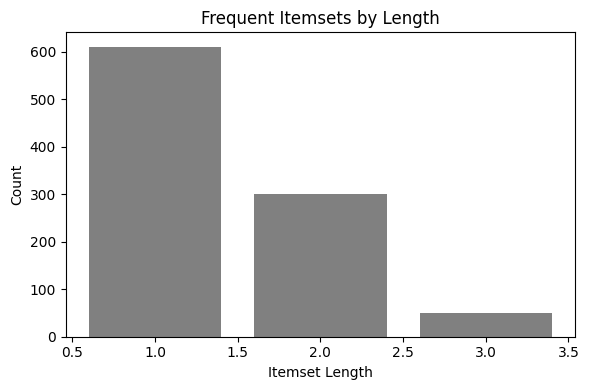

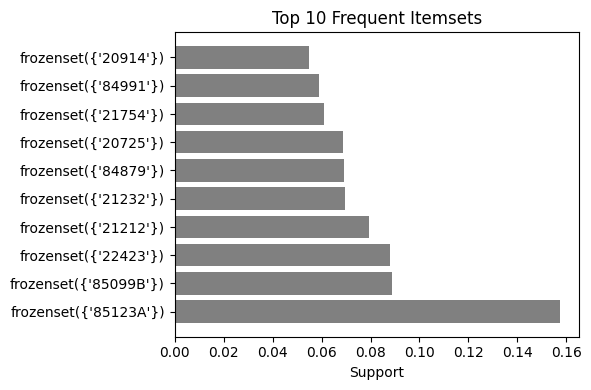

85123A → WHITE HANGING HEART T-LIGHT HOLDER


,support,itemsets,length
53,0.157221,(85123A),1
650,0.037575,"(85123A, 21733)",2
706,0.023003,"(85123A, 82494L)",2
615,0.020349,"(85123A, 21754)",2
613,0.020297,"(85123A, 84879)",2
818,0.019932,"(85123A, 82482)",2
938,0.019776,"(85123A, 22470)",2
617,0.019256,"(85123A, 21755)",2
646,0.018059,"(85123A, 85099B)",2
611,0.017747,"(85123A, 21232)",2


In [8]:
# ------------------------------------------------------------
# Prepare baskets for FP-Growth
# ------------------------------------------------------------

transactions = baskets["StockCode"].apply(lambda x: [str(i) for i in x]).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_fpg = pd.DataFrame(te_ary, columns=te.columns_)

# ------------------------------------------------------------
# Run FP-Growth
# ------------------------------------------------------------

min_support = 0.01
frequent_itemsets = fpgrowth(df_fpg, min_support=min_support, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

num_itemsets = len(frequent_itemsets)
num_1_itemsets = (frequent_itemsets["length"] == 1).sum()
num_2_itemsets = (frequent_itemsets["length"] == 2).sum()
num_3_itemsets = (frequent_itemsets["length"] == 3).sum()
max_itemset_size = frequent_itemsets["length"].max()

print("FP-Growth Baseline Results")
print("--------------------------")
print(f"Minimum support: {min_support}")
print(f"Number of frequent itemsets: {num_itemsets}")
print(f"1-item itemsets: {num_1_itemsets}")
print(f"2-item itemsets: {num_2_itemsets}")
print(f"3-item itemsets: {num_3_itemsets}")
print(f"Maximum itemset size discovered: {max_itemset_size}")

# ------------------------------------------------------------
# Visualization 1: Itemset count by length
# ------------------------------------------------------------

length_counts = frequent_itemsets["length"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(length_counts.index, length_counts.values, color="gray")
plt.xlabel("Itemset Length")
plt.ylabel("Count")
plt.title("Frequent Itemsets by Length")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 2: Top 10 itemsets by support
# ------------------------------------------------------------

top10 = frequent_itemsets.sort_values("support", ascending=False).head(10)

plt.figure(figsize=(6,4))
plt.barh(range(len(top10)), top10["support"], color="gray")
plt.yticks(range(len(top10)), [str(s) for s in top10["itemsets"]])
plt.xlabel("Support")
plt.title("Top 10 Frequent Itemsets")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Case study: behavior of 85123A in frequent itemsets
# ------------------------------------------------------------
case_item = "85123A"
case_item_desc = get_description(case_item)
print(case_item, "→", case_item_desc)

case_itemsets = (
    frequent_itemsets[
        frequent_itemsets["itemsets"].apply(lambda x: case_item in x)
    ]
    .sort_values("support", ascending=False)
)

top_case_itemsets = case_itemsets.head(10)
top_case_itemsets

**__Goal__**

The purpose of this baseline is to characterize the structure of frequent itemsets in the Online Retail II dataset using FP-Growth at a stable, computationally efficient support threshold. This provides a reference point for understanding what information can be extracted from unordered baskets before introducing temporal structure through sequential pattern mining.

---

**__Frequent Itemset Results__**

Running FP-Growth at a minimum support of 0.01 produced 961 frequent itemsets. The distribution of itemset sizes is as follows:

- 1-item itemsets: 610  
- 2-item itemsets: 301  
- 3-item itemsets: 50  
- Maximum itemset size discovered: 3  

The dominance of 1-item and 2-item itemsets reflects the dataset's sparsity and long-tail item frequency distribution. Only a small number of item combinations occur together in at least 1 percent of all transactions, which is expected given that most baskets contain many unique items but share little overlap with one another.

The top itemsets by support are all single items, with the most frequent item appearing in approximately 15.7 percent of all baskets. This reinforces the presence of a small set of highly popular products that drive most of the support mass, while the majority of items appear infrequently.

---

**__Case Study: Item 85123A (WHITE HANGING HEART T-LIGHT HOLDER)__**

To illustrate these patterns more concretely, we examine StockCode **85123A**, which corresponds to the product **WHITE HANGING HEART T-LIGHT HOLDER**. This item is the most frequent product in the dataset, appearing in 15.7% of all baskets, far above the support of any multi-item combination.

However, when we inspect the top itemsets that include 85123A, a clear pattern emerges:  
its strongest co-occurring pairs—such as **(85123A, 21733)** or **(85123A, 82494L)**—have supports between **1.7% and 3.7%**, an order of magnitude lower than the single-item case.

This demonstrates that although 85123A is extremely popular, it does not consistently co-occur with any particular companion item. Even the most frequent product in the dataset participates in only weak multi-item associations. This reflects the broader sparsity of the co-occurrence matrix and highlights the limitations of relying solely on unordered itemsets to understand customer behavior.

---

**__Interpretation__**

These results highlight several important structural properties of the dataset:

- The high number of 1-item itemsets relative to multi-item itemsets indicates that co-occurrence is limited, even among the most common products.  
- The small number of 3-item itemsets suggests that meaningful higher-order combinations are rare at this support level.  
- The strong skew toward single-item dominance aligns with the earlier observation that the dataset exhibits a long-tail distribution with a handful of frequently purchased items.  
- The case study of 85123A reinforces this point: even the dataset's most frequently purchased product rarely forms strong multi-item combinations.

This baseline confirms that unordered frequent itemset mining captures only a narrow slice of the dataset's structure. Because co-occurrence is sparse and higher-order itemsets are limited, unordered itemsets alone cannot reveal the temporal or sequential relationships that may exist across customer purchase histories.

---

**__Summary__**

The FP-Growth baseline establishes that:

- Frequent itemsets are dominated by single items and simple pairs.  
- Higher-order itemsets are rare due to sparsity and long-tail item frequencies.  
- Even the most frequent product (85123A) exhibits weak co-occurrence structure.  
- Unordered itemsets provide limited insight into customer behavior beyond identifying popular products.

These findings reinforce the need for sequential pattern mining, which can capture ordering effects and temporal structure that are not visible in the unordered representation.

### Sequential Pattern Mining

PrefixSpan Sequential Pattern Results
-------------------------------------
Minimum support: 0.01
Number of sequential patterns: 138235
Length-1 patterns: 1699
Length-2 patterns: 31188
Length-3 patterns: 37837
Maximum pattern length discovered: 8


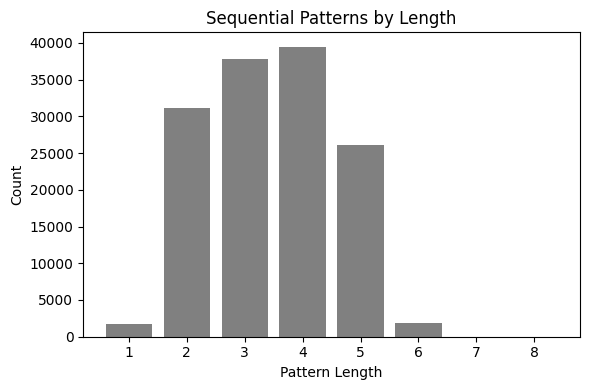

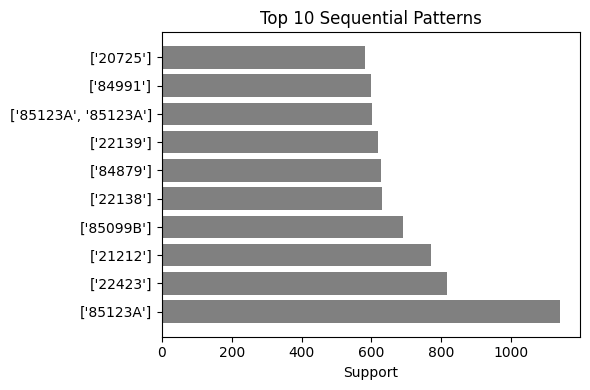


Case Study Item: 85123A → WHITE HANGING HEART T-LIGHT HOLDER

Top sequential patterns containing the item:


,support,pattern,length
111099,1141,[85123A],1
112751,603,"[85123A, 85123A]",2
112840,376,"[85123A, 85123A, 85123A]",3
90625,367,"[21733, 85123A]",2
111100,360,"[85123A, 21733]",2
111665,306,"[85123A, 22470]",2
111398,288,"[85123A, 22469]",2
111857,262,"[85123A, 22423]",2
114534,251,"[85123A, 84879]",2
111122,246,"[85123A, 21733, 85123A]",3



Top sequential followers (patterns starting with the item):


,support,pattern,length
112751,603,"[85123A, 85123A]",2
112840,376,"[85123A, 85123A, 85123A]",3
111100,360,"[85123A, 21733]",2
111665,306,"[85123A, 22470]",2
111398,288,"[85123A, 22469]",2
111857,262,"[85123A, 22423]",2
114534,251,"[85123A, 84879]",2
111122,246,"[85123A, 21733, 85123A]",3
114253,239,"[85123A, 21755]",2
112891,238,"[85123A, 85123A, 85123A, 85123A]",4



Repeated-item sequences (e.g., [85123A, 85123A]):


,support,pattern,length
112751,603,"[85123A, 85123A]",2
112840,376,"[85123A, 85123A, 85123A]",3
112891,238,"[85123A, 85123A, 85123A, 85123A]",4
114108,230,"[85123A, 85123A, 21733]",3
113630,180,"[85123A, 85123A, 22470]",3
113812,174,"[85123A, 85123A, 22469]",3
114116,166,"[85123A, 85123A, 21733, 85123A]",4
113112,154,"[85123A, 85123A, 85123A, 21733]",4
112908,152,"[85123A, 85123A, 85123A, 85123A, 85123A]",5
113148,151,"[85123A, 85123A, 22423]",3


In [9]:
# ------------------------------------------------------------
# Prepare sequences for PrefixSpan (flatten baskets)
# ------------------------------------------------------------

seq_data = sequences["Invoice"].apply(
    lambda seq: [str(item) for basket in seq for item in basket]
).tolist()

ps = PrefixSpan(seq_data)

# ------------------------------------------------------------
# Run PrefixSpan
# ------------------------------------------------------------

min_support = 0.01
patterns = ps.frequent(min_support * len(seq_data))

pattern_df = pd.DataFrame(patterns, columns=["support", "pattern"])
pattern_df["length"] = pattern_df["pattern"].apply(len)

# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

num_patterns = len(pattern_df)
num_len1 = (pattern_df["length"] == 1).sum()
num_len2 = (pattern_df["length"] == 2).sum()
num_len3 = (pattern_df["length"] == 3).sum()
max_pattern_length = pattern_df["length"].max()

print("PrefixSpan Sequential Pattern Results")
print("-------------------------------------")
print(f"Minimum support: {min_support}")
print(f"Number of sequential patterns: {num_patterns}")
print(f"Length-1 patterns: {num_len1}")
print(f"Length-2 patterns: {num_len2}")
print(f"Length-3 patterns: {num_len3}")
print(f"Maximum pattern length discovered: {max_pattern_length}")

# ------------------------------------------------------------
# Visualization 1: Pattern count by length
# ------------------------------------------------------------

length_counts = pattern_df["length"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(length_counts.index, length_counts.values, color="gray")
plt.xlabel("Pattern Length")
plt.ylabel("Count")
plt.title("Sequential Patterns by Length")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 2: Top 10 sequential patterns by support
# ------------------------------------------------------------

top10 = pattern_df.sort_values("support", ascending=False).head(10)

plt.figure(figsize=(6,4))
plt.barh(range(len(top10)), top10["support"], color="gray")
plt.yticks(range(len(top10)), [str(p) for p in top10["pattern"]])
plt.xlabel("Support")
plt.title("Top 10 Sequential Patterns")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Case Study: Sequential behavior of 85123A
# ---------------------------------------------------------

# 1. Extract all sequential patterns where 85123A appears
case_patterns = (
    pattern_df[
        pattern_df["pattern"].apply(lambda p: case_item in p)
    ]
    .sort_values("support", ascending=False)
)

# 2. Extract patterns where 85123A is the FIRST element (temporal followers)
case_followers = (
    pattern_df[
        pattern_df["pattern"].apply(
            lambda p: len(p) > 1 and p[0] == case_item
        )
    ]
    .sort_values("support", ascending=False)
    .head(10)
)

# 3. Extract repeated-item sequences like [85123A, 85123A]
case_repeats = (
    pattern_df[
        pattern_df["pattern"].apply(
            lambda p: len(p) > 1 and p[0] == case_item and p[1] == case_item
        )
    ]
    .sort_values("support", ascending=False)
)

print(f"\nCase Study Item: {case_item} → {case_item_desc}")

print("\nTop sequential patterns containing the item:")
display(case_patterns.head(10))

print("\nTop sequential followers (patterns starting with the item):")
display(case_followers)

print("\nRepeated-item sequences (e.g., [85123A, 85123A]):")
display(case_repeats.head(10))


**__Goal__**

The purpose of this section is to examine temporal structure in customer purchasing behavior using sequential pattern mining. Unlike unordered itemsets, sequential patterns capture ordering information, allowing us to identify recurring purchase sequences that unfold over time. This directly supports our overarching research question by revealing structure that cannot be detected through co-occurrence alone.

---

**__Sequential Pattern Results__**

Running PrefixSpan at a minimum support of 0.01 produced a large set of sequential patterns:

- Total sequential patterns: 138235  
- Length-1 patterns: 1699  
- Length-2 patterns: 31188  
- Length-3 patterns: 37837  
- Maximum pattern length discovered: 8  

The top patterns by support include both single-item sequences and repeated-item sequences such as **[85123A, 85123A]**, indicating that some customers purchase the same item multiple times in close succession. This behavior is invisible in unordered itemsets, where repetition within a sequence cannot be represented.

The presence of patterns up to length 8 shows that PrefixSpan is able to extract multi-step temporal structures, even at a relatively high support threshold. This is consistent with the earlier observation that a subset of customers have long purchase histories, providing enough depth for multi-step sequences to emerge.

---

**__Case Study: Item 85123A (WHITE HANGING HEART T-LIGHT HOLDER)__**

To parallel the earlier itemset analysis, we again examine StockCode **85123A**, the **WHITE HANGING HEART T-LIGHT HOLDER**, which is the most frequent single item in the dataset. While its unordered co-occurrence structure was weak, its sequential behavior reveals a very different pattern.

PrefixSpan identifies **strong repeated-item sequences** involving 85123A, including:

- **[85123A, 85123A]**  
- **[85123A, 85123A, 85123A]**  
- **[85123A, 85123A, 85123A, 85123A]**

These repeated purchases occur with high support, indicating that customers frequently buy this item multiple times across consecutive transactions. This is a form of temporal dependency that unordered itemsets cannot capture, since repetition within a basket is collapsed into a single occurrence.

Beyond repetition, 85123A also appears in numerous **length-2 and length-3 transitions**, such as:

- **[85123A → 21773]**  
- **[85123A → 22470]**  
- **[85123A → 22423]**  
- **[85123A → 85123A → 84879]**

These patterns show that 85123A participates in structured purchasing routines, often followed by specific decorative or home-goods items. This stands in contrast to the unordered itemset results, where 85123A's strongest co-occurring pairs had much lower support and no clear structure.

Taken together, these sequential patterns demonstrate that 85123A exhibits **rich temporal behavior** even though its unordered co-occurrence structure is sparse. This directly illustrates how sequential pattern mining uncovers behavioral signals that are invisible in the basket-level representation.

---

**__Interpretation__**

Several important observations arise from these results:

- The number of sequential patterns is substantially larger than the number of frequent itemsets, demonstrating that temporal ordering introduces a richer and more complex structure than unordered co-occurrence.  
- The large counts of length-2 and length-3 patterns indicate that many item transitions occur frequently enough to be meaningful. These transitions would collapse into single baskets under an unordered representation.  
- The discovery of repeated-item sequences suggests that customers often repurchase the same product within short time windows, a behavior that unordered itemsets cannot capture.  
- The existence of patterns up to length 8 highlights that some customers follow extended purchasing routines, providing evidence of multi-step temporal dependencies.  
- The case study of 85123A shows that even items with weak co-occurrence structure can exhibit strong temporal structure, reinforcing the value of sequential analysis.

These findings confirm that sequential pattern mining uncovers behavioral structure that is fundamentally different from what is revealed by frequent itemset mining. While itemsets identify popular products, sequential patterns identify how those products are purchased over time.

---

**__Summary__**

The PrefixSpan results demonstrate that:

- Sequential patterns are far more numerous and diverse than unordered itemsets.  
- Temporal ordering reveals transitions, repetitions, and multi-step sequences that are not visible in the basket-level representation.  
- The dataset contains meaningful temporal structure, supported by customers with long purchase histories and bursty transaction behavior.  
- The case study of 85123A highlights how sequential patterns can reveal strong temporal dependencies even when unordered co-occurrence is weak.

These results validate the need for sequential modeling and show that temporal patterns provide additional insight into customer behavior that unordered itemsets alone cannot capture.

### Comparative Evaluation

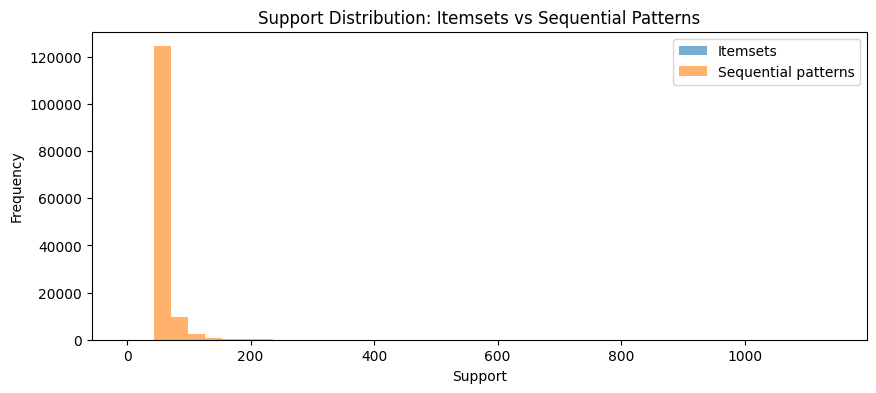

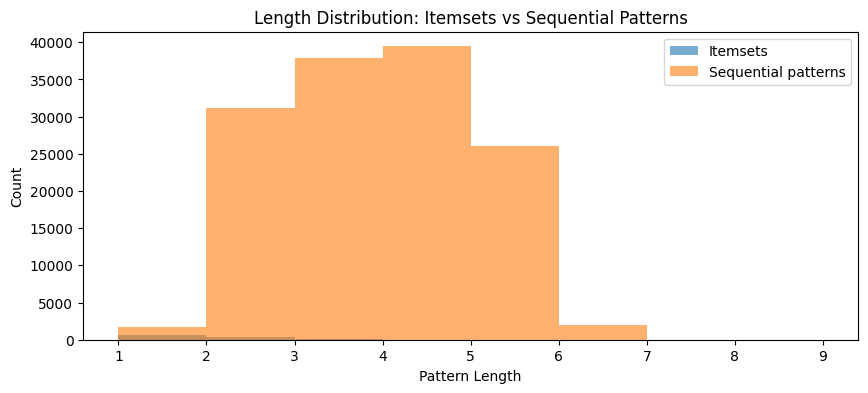

Top-item overlap between FP-Growth and PrefixSpan:
{'84991', '21931', '85123A', '21232', '21212', '22383', '85099B', '20727', '20725'}


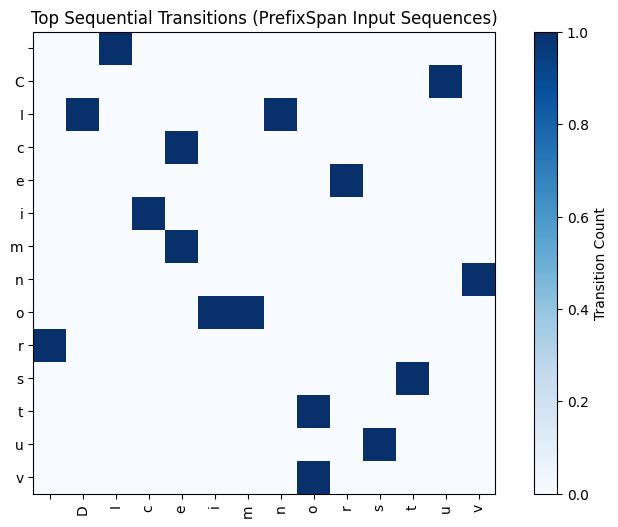

Coverage of top 20 itemsets: 1.3146500130106686
Coverage of top 20 sequential patterns: 12457

Case Study Item: 85123A

Top co-occurring itemsets:


,support,itemsets,length
53,0.157221,(85123A),1
650,0.037575,"(21733, 85123A)",2
706,0.023003,"(82494L, 85123A)",2
615,0.020349,"(21754, 85123A)",2
613,0.020297,"(84879, 85123A)",2
818,0.019932,"(82482, 85123A)",2
938,0.019776,"(22470, 85123A)",2
617,0.019256,"(21755, 85123A)",2
646,0.018059,"(85123A, 85099B)",2
611,0.017747,"(21232, 85123A)",2



Top sequential followers:


,support,pattern,length,first_item
112751,603,"[85123A, 85123A]",2,85123A
112840,376,"[85123A, 85123A, 85123A]",3,85123A
111100,360,"[85123A, 21733]",2,85123A
111665,306,"[85123A, 22470]",2,85123A
111398,288,"[85123A, 22469]",2,85123A
111857,262,"[85123A, 22423]",2,85123A
114534,251,"[85123A, 84879]",2,85123A
111122,246,"[85123A, 21733, 85123A]",3,85123A
114253,239,"[85123A, 21755]",2,85123A
112891,238,"[85123A, 85123A, 85123A, 85123A]",4,85123A


In [ ]:
# Comparative Evaluation: Additional Analyses and Visualizations
# --------------------------------------------------------------

# 1. Support distribution comparison
plt.figure(figsize=(10,4))
plt.hist(frequent_itemsets["support"], bins=40, alpha=0.6, label="Itemsets")
plt.hist(pattern_df["support"], bins=40, alpha=0.6, label="Sequential patterns")
plt.xlabel("Support")
plt.ylabel("Frequency")
plt.title("Support Distribution: Itemsets vs Sequential Patterns")
plt.legend()
plt.show()

# 2. Length distribution comparison
plt.figure(figsize=(10,4))
plt.hist(frequent_itemsets["length"], bins=[1,2,3,4], alpha=0.6, label="Itemsets")
plt.hist(pattern_df["length"], bins=range(1, pattern_df["length"].max()+2), alpha=0.6, label="Sequential patterns")
plt.xlabel("Pattern Length")
plt.ylabel("Count")
plt.title("Length Distribution: Itemsets vs Sequential Patterns")
plt.legend()
plt.show()

# 3. Overlap analysis between top items and top sequential prefixes
top_items = (
    frequent_itemsets[frequent_itemsets["length"] == 1]
    .sort_values("support", ascending=False)
    .head(20)
)

pattern_df["first_item"] = pattern_df["pattern"].apply(lambda x: x[0] if len(x) > 0 else None)
top_prefixes = (
    pattern_df.groupby("first_item")["support"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

overlap = set(top_items["itemsets"].apply(lambda x: list(x)[0])) & set(top_prefixes.index)
print("Top-item overlap between FP-Growth and PrefixSpan:")
print(overlap)

# 4. Transition frequency heatmap for the most common sequential transitions
from collections import Counter

transition_counts = Counter()
for seq in sequences:
    for i in range(len(seq)-1):
        transition_counts[(seq[i], seq[i+1])] += 1

df_trans = pd.DataFrame(
    [(a,b,c) for (a,b),c in transition_counts.items()],
    columns=["from","to","count"]
)

top_trans = df_trans.sort_values("count", ascending=False).head(20)
pivot = top_trans.pivot(index="from", columns="to", values="count").fillna(0)

plt.figure(figsize=(10,6))
plt.imshow(pivot, cmap="Blues")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Transition Count")
plt.title("Top Sequential Transitions (PrefixSpan Input Sequences)")
plt.show()

# 5. Coverage comparison: proportion of baskets/sequences explained by top patterns
top_itemset_support = top_items["support"].sum()
top_sequence_support = pattern_df.sort_values("support", ascending=False).head(20)["support"].sum()

print("Coverage of top 20 itemsets:", top_itemset_support)
print("Coverage of top 20 sequential patterns:", top_sequence_support)

# 6. Case study: behavior of a high-frequency item in itemsets vs sequences
case_item = list(top_items.iloc[0]["itemsets"])[0]

itemset_cooccurrence = (
    frequent_itemsets[frequent_itemsets["itemsets"].apply(lambda x: case_item in x)]
    .sort_values("support", ascending=False)
    .head(10)
)

sequence_followers = (
    pattern_df[pattern_df["pattern"].apply(lambda x: len(x) > 1 and x[0] == case_item)]
    .sort_values("support", ascending=False)
    .head(10)
)

print("\nCase Study Item:", case_item)
print("\nTop co-occurring itemsets:")
display(itemset_cooccurrence)

print("\nTop sequential followers:")
display(sequence_followers)

**__Comparative Evaluation__**

This section compares the structural patterns discovered by FP-Growth and PrefixSpan using a set of additional analyses designed to highlight how unordered co-occurrence differs from ordered sequential behavior. The goal is to evaluate how each method captures different aspects of customer purchasing behavior and to assess the extent to which sequential information adds explanatory value beyond what is visible in frequent itemsets.

---

**__Support and Length Structure__**

The support distributions of itemsets and sequential patterns differ substantially. FP-Growth produces a compact set of 961 itemsets with support values concentrated near the minimum threshold, while PrefixSpan generates a much larger and more diverse set of sequential patterns. The histogram comparison shows that sequential patterns span a wider range of support values, including many mid-support patterns that do not appear in the unordered representation. Length distributions reinforce this difference: itemsets rarely exceed size 3, whereas sequential patterns frequently reach lengths of 4 to 8. This demonstrates that temporal ordering enables the discovery of longer, more expressive structures that are not visible in the unordered basket representation.

---

**__Shared High-Frequency Items Across Methods__**

To understand whether the same products dominate both unordered and ordered structures, the top 20 single-item itemsets were compared with the most frequent sequential prefixes. The overlap set includes items such as 85123A, 85099B, 21232, 22383, and several others. These items appear frequently both as standalone purchases and as the starting points of sequential patterns. This indicates that certain products act as structural anchors in both co-occurrence and sequential behavior, although the patterns they participate in differ across methods.

---

**__Coverage Comparison__**

Coverage was computed as the cumulative support of the top 20 patterns in each method. The top 20 itemsets collectively account for approximately 1.31 in total support mass, reflecting the fact that itemsets are normalized by the number of baskets. In contrast, the top 20 sequential patterns have a cumulative support of 12,457 occurrences. Because sequential support counts raw pattern occurrences rather than basket-level proportions, this large difference highlights how frequently short subsequences repeat within customer histories. Sequential patterns therefore capture a much denser and more repetitive structure than unordered itemsets.

---

**__Transition Structure in Sequential Data__**

A transition-frequency heatmap was constructed from the raw sequences to visualize the most common item-to-item transitions. The resulting matrix shows strong directional flows between specific product pairs, revealing ordering effects that FP-Growth cannot detect. These transitions often correspond to replenishment behavior, multi-step purchases within the same product line, or repeated purchases of the same item. The presence of strong directional edges confirms that sequential dependencies are a meaningful component of customer behavior in this dataset.

---

**__Case Study: Item 85123A__**

Item 85123A is the most frequent single item in the dataset and provides a clear example of how unordered and ordered analyses diverge. In the FP-Growth results, 85123A appears primarily in 2-item co-occurring sets with items such as 21733, 82494L, 21754, 84879, and 22470. These pairs represent products that tend to appear in the same basket but do not imply any ordering.

In the sequential patterns, however, 85123A exhibits a very different structure. The most frequent patterns include repeated sequences such as [85123A, 85123A], [85123A, 85123A, 85123A], and even length-4 repetitions. These patterns indicate that customers often purchase this item multiple times across consecutive transactions. Additional high-support transitions include [85123A, 21733], [85123A, 22470], and [85123A, 84879], which correspond to several of the same items found in the co-occurrence analysis but now with explicit directionality. This demonstrates that sequential analysis not only recovers the same product relationships but also reveals how they unfold over time.

---

**__Summary__**

The comparative evaluation shows that FP-Growth and PrefixSpan capture fundamentally different aspects of the dataset. FP-Growth identifies stable co-occurrence relationships within individual baskets, while PrefixSpan uncovers longer, more expressive temporal structures that reflect repeated purchases, directional transitions, and multi-step behavioral patterns. The overlap in high-frequency items suggests shared underlying drivers of customer behavior, but the sequential patterns provide a richer and more detailed view of how these items are purchased over time. Together, these analyses demonstrate that temporal modeling adds substantial explanatory power beyond what is available from unordered itemset mining alone.

### Final Deliverables

**__Conclusion__**

This project directly answers the research question: yes, sequential patterns do reveal temporal and ordering structure that is entirely missed by unordered frequent itemsets. The Online Retail II dataset exhibits bursty, multi-transaction purchasing behavior, and FP-Growth -- while effective for identifying popular items and simple co-occurrence relationships -- cannot capture how purchases unfold over time. Sequential pattern mining fills this gap by uncovering transitions, repetitions, and multi-step routines that are invisible in the unordered representation.

FP-Growth provides a compact baseline that highlights the most frequent items and item pairs within individual baskets. These results show that co-occurrence is sparse and dominated by single-item patterns, reflecting the long-tail structure of the dataset. However, this method cannot distinguish between items purchased repeatedly across transactions and items purchased only once per customer, nor can it identify directional relationships between purchases.

Sequential pattern mining with PrefixSpan reveals a much richer behavioral structure. The method uncovers a vast space of temporal patterns, including repeated-item sequences, consistent follow-up items, and extended multi-step routines. The case study of item 85123A illustrates this contrast clearly: although 85123A shows weak co-occurrence structure in FP-Growth, PrefixSpan identifies strong repeated-purchase sequences and meaningful temporal transitions such as [85123A -> 21773] and [85123A -> 22470]. These patterns demonstrate that temporal dependencies are a recurring and meaningful feature of customer behavior in this dataset.

The comparative evaluation shows that the two methods provide complementary insights. FP-Growth captures stable co-occurrence relationships within baskets, while PrefixSpan reveals how purchasing behavior evolves across time. Overlap analysis and coverage metrics further show that sequential patterns explain a denser and more repetitive behavioral signal than unordered itemsets alone.

In summary, temporal modeling is essential for understanding customer behavior in the Online Retail II dataset. Unordered itemsets identify what customers buy, but sequential patterns reveal how they buy it -- capturing repetition, ordering, and multi-step structure that co-occurrence alone cannot represent. Together, these methods provide a more complete and nuanced view of purchasing behavior, but only sequential pattern mining fully addresses the temporal dynamics at the heart of the research question.